### Inizializzazione e Caricamento del Dataset Pulito
Importando le librerie necessarie e caricando il dataset che abbiamo precedentemente pulito e ottimizzato. Questo dataset contiene solo le variabili più rilevanti per la previsione del successo accademico

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

pd.set_option('display.max_columns', None)

# Assicurati che il nome del file sia esattamente quello che hai salvato
file_path = 'datasets/cleaned_dataset.csv' 

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset pulito caricato con successo! Dimensioni: {df.shape}")
else:
    print("ERRORE: Il dataset pulito non è stato trovato.")

Dataset pulito caricato con successo! Dimensioni: (3630, 24)


### Pre-processing: One-Hot Encoding
Dato che gli algoritmi di Machine Learning richiedono input numerici le macro-categorie testuali create nella fase di Feature Engineering come 'Higher_Education', 'Secondary_Education', ecc... devono essere convertite. Utilizziamo la tecnica del One-Hot Encoding per trasformarle in variabili binarie (dummy variables), applicando l'argomento `drop_first=True` per evitare la trappola della multicollinearità (Dummy Variable Trap)
Es. se abbiamo 'Higher_Education' = 0 e 'Secondary_Education' = 0 allora per forza Basic_or_Unknown = 1 mentre se almeno una delle 2 precedenti fosse uguale a 1 allora le altre starebbero a 0 di conseguenza non ha senso avere Basic_or_Unknown tra le colonne

In [2]:
#Convertiamo le colonne testuali in colonne binarie (0/1)
#drop_first=True rimuove una delle categorie per ogni colonna per non creare informazioni ridondanti matematicamente
#dtype=int forza l'output a essere 0/1 invece di False/True (utile per le versioni recenti di Pandas)

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

print(f"Dimensioni del dataset dopo l'encoding: {df_encoded.shape}")

#Vediamo un'occhiata a come sono diventate le nuove colonne
df_encoded.head()

Dimensioni del dataset dopo l'encoding: (3630, 28)


,Application mode,Daytime/evening attendance,Previous qualification,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Target,Mother's qualification_Higher_Education,Mother's qualification_Secondary_Education,Father's qualification_Higher_Education,Father's qualification_Secondary_Education,Mother's occupation_Skilled_or_Clerical,Mother's occupation_Unskilled_or_Inactive,Father's occupation_Skilled_or_Clerical,Father's occupation_Unskilled_or_Inactive
0,8,1,1,1,0,0,1,1,0,20,0,0,0,0,0.000000,0,0,0,0.000000,0,0,1,0,1,1,0,1,0
1,6,1,1,1,0,0,0,1,0,19,0,6,6,6,14.000000,6,6,6,13.666667,1,0,1,1,0,1,0,1,0
2,1,1,1,1,0,0,0,1,0,19,0,6,0,0,0.000000,6,0,0,0.000000,0,0,1,0,1,1,0,1,0
3,8,1,1,1,0,0,1,0,0,20,0,6,8,6,13.428571,6,10,5,12.400000,1,0,0,0,1,1,0,1,0
4,12,0,1,0,0,0,1,0,0,45,0,6,9,5,12.333333,6,6,6,13.000000,1,0,1,0,0,1,0,1,0


### Split dei Dati: Feature (X) e Target (y)
Separiamo la variabile dipendente (`Target`) dalle variabili indipendenti (tutte le altre feature). Questo ci permette di isolare l'obiettivo della nostra previsione

In [3]:
# X contiene tutto tranne il Target
X = df_encoded.drop('Target', axis=1)

# y contiene solo il Target
y = df_encoded['Target']

print(f"Feature selezionate: {X.shape[1]}")
print(f"Target isolato correttamente.")

Feature selezionate: 27
Target isolato correttamente.


### Suddivisione in Training e Test Set
Utilizziamo `train_test_split` per dividere i dati. Destiniamo il 20% del dataset al test finale per valutare l'efficacia del modello su dati mai visti prima. Impostiamo un `random_state` per garantire che i risultati siano riproducibili.

In [4]:
from sklearn.model_selection import train_test_split

# Dividiamo con proporzione 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Esempi per l'addestramento: {len(X_train)}")
print(f"Esempi per il test: {len(X_test)}")

Esempi per l'addestramento: 2904
Esempi per il test: 726


### Addestramento del Modello: Regressione Logistica
Procediamo con il primo modello di classificazione. Utilizzeremo i dati di addestramento (`X_train`, `y_train`) per permettere al modello di imparare le relazioni tra le feature e il successo accademico. Aumentiamo il numero di iterazioni (`max_iter`) per assicurarci che l'algoritmo trovi la soluzione ottimale.

In [5]:
from sklearn.linear_model import LogisticRegression

# Inizializziamo il modello
# random_state=42 serve per avere sempre gli stessi risultati ogni volta che esegui la cella
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Addestramento vero e proprio
model_lr.fit(X_train, y_train)

print("✅ Modello di Regressione Logistica addestrato con successo!")

✅ Modello di Regressione Logistica addestrato con successo!


### Valutazione delle Performance
Valutiamo il modello sui dati di test (`X_test`). Analizzeremo la Matrice di Confusione per osservare visivamente gli errori e il Classification Report per ottenere metriche fondamentali come Precision, Recall e F1-Score

REPORT DI CLASSIFICAZIONE:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       284
           1       0.90      0.97      0.93       442

    accuracy                           0.92       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.92      0.91       726



<Figure size 800x600 with 0 Axes>

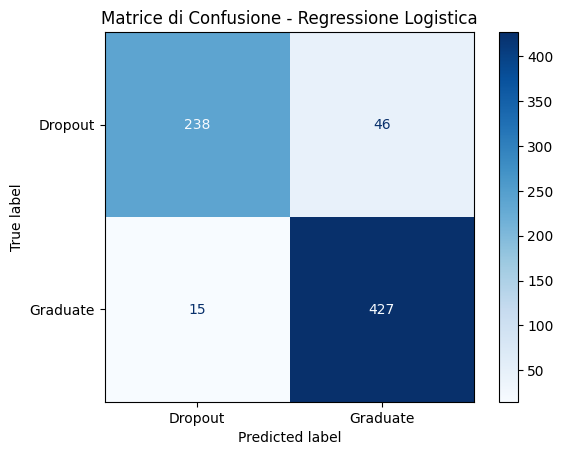

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Effettuiamo le previsioni sui dati che il modello non ha mai visto
y_pred_lr = model_lr.predict(X_test)

# Stampiamo il report testuale
print("REPORT DI CLASSIFICAZIONE:")
print(classification_report(y_test, y_pred_lr))

# Creiamo il grafico della Matrice di Confusione
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dropout', 'Graduate'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matrice di Confusione - Regressione Logistica')
plt.show()

### Modello Avanzato: Random Forest Classifier
Proviamo a migliorare le performance utilizzando un modello basato su ensemble di alberi decisionali. Il Random Forest è in grado di catturare relazioni non lineari tra le variabili che potrebbero sfuggire alla Regressione Logistica. Valuteremo se la complessità aggiuntiva porta a un reale incremento dell'accuratezza.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Inizializziamo il Random Forest con 100 alberi
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Addestramento
model_rf.fit(X_train, y_train)

# Previsioni e Report
y_pred_rf = model_rf.predict(X_test)

print("REPORT DI CLASSIFICAZIONE - Random Forest:")
print(classification_report(y_test, y_pred_rf))

REPORT DI CLASSIFICAZIONE - Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.84      0.88       284
           1       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



### 8. Analisi dell'Importanza delle Feature
Uno dei vantaggi del Random Forest è la capacità di quantificare quanto ogni variabile contribuisca alla previsione finale. Visualizziamo le prime 10 variabili più influenti per capire quali fattori (voti, background familiare, dati socio-economici) determinano maggiormente il successo o l'abbandono dello studente

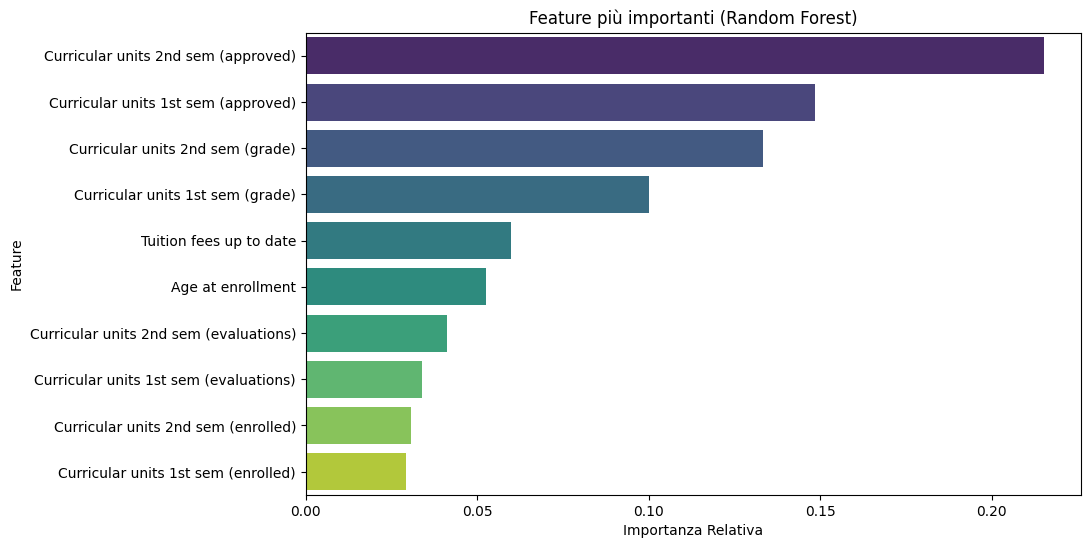

In [32]:
# Estraiamo l'importanza delle feature
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Ordiniamo e prendiamo le prime 10
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Creazione del grafico
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature',       # Specifichiamo che il colore dipende dalla feature
    palette='viridis', 
    legend=False         # Togliamo la legenda che sarebbe ridondante
)
plt.title('Feature più importanti (Random Forest)')
plt.xlabel('Importanza Relativa')
plt.ylabel('Feature')
plt.show()

### Analisi della Confidenza del Modello (Distribuzione delle Probabilità)
Mentre la Matrice di Confusione ci dice cosa ha previsto il modello, questo istogramma ci mostra quanto il modello è sicuro delle proprie previsioni.
Il modello assegna a ogni studente una probabilità da 0 a 1 di appartenere alla classe 'Graduate':

Valori vicino a 0: Il modello è molto sicuro che lo studente sia a rischio abbandono (Dropout).

Valori vicino a 1: Il modello è molto sicuro che lo studente completerà gli studi (Graduate).

Zona centrale (intorno a 0.5): Rappresenta gli studenti per i quali il modello è incerto.

Una distribuzione con due picchi netti alle estremità (come in questo caso) indica un modello robusto che riesce a distinguere chiaramente le due classi, riducendo al minimo i casi dubbi

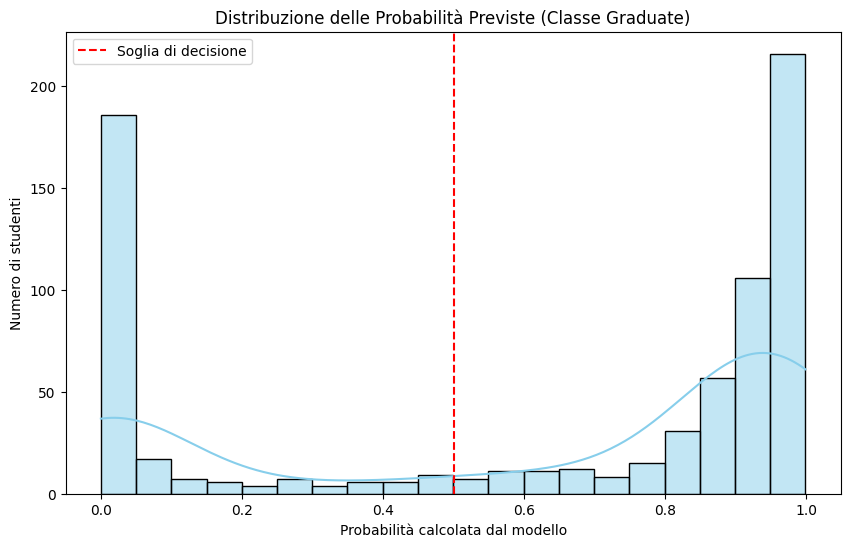

In [ ]:
# Calcoliamo le probabilità invece delle classi nette
y_probs = model_lr.predict_proba(X_test)[:, 1]

plt.figure(figsize=(14, 10))
sns.histplot(y_probs, bins=20, kde=True, color='skyblue')
plt.axvline(x=0.5, color='red', linestyle='--', label='Soglia di decisione')

plt.title('Distribuzione delle Probabilità Previste (Classe Graduate)')
plt.xlabel('Probabilità calcolata dal modello')
plt.ylabel('Numero di studenti')
plt.legend()
plt.show()